# **Cell 1: Install Dependencies**

In [1]:
%%capture
!pip install -q torch torchvision grad-cam scikit-learn matplotlib seaborn efficientnet-pytorch

# **Cell 2: Import Libraries**

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# **Cell 3: Download Dataset from Kaggle**

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/ 2>/dev/null || true
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null || true

!rm -rf data/
!kaggle datasets download -d lukechugh/best-alzheimer-mri-dataset-99-accuracy
!unzip -q -o best-alzheimer-mri-dataset-99-accuracy.zip -d data/
!rm best-alzheimer-mri-dataset-99-accuracy.zip

Dataset URL: https://www.kaggle.com/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy
License(s): MIT
100% 71.5M/71.5M [00:04<00:00, 15.3MB/s]



# **Cell 4: Detect Dataset Path and Define Transforms**

In [4]:
BASE = "data"
DATA_DIR = None

for root, dirs, _ in os.walk(BASE):
    if "train" in dirs and "test" in dirs:
        DATA_DIR = root
        break

print(f"DATA_DIR = {DATA_DIR}")
print(f"Contents: {os.listdir(DATA_DIR)}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

DATA_DIR = data/Combined Dataset
Contents: ['test', 'train']


# **Cell 5: Custom Safe ImageFolder and Load Datasets**

In [5]:
def safe_loader(path):
    try:
        with open(path, 'rb') as f:
            img = Image.open(f)
            img = img.convert("RGB")
            return img
    except Exception:
        return Image.new("RGB", (224, 224), (0, 0, 0))

class SafeImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        self.loader = safe_loader

train_dataset = SafeImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
test_dataset = SafeImageFolder(os.path.join(DATA_DIR, "test"), transform=val_test_transform)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

# Count per class
from collections import Counter
counts = Counter(train_dataset.targets)
for i, cls in enumerate(train_dataset.classes):
    print(f"  {cls}: {counts[i]}")

Train: 10240 | Test: 1279
Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
  Mild Impairment: 2560
  Moderate Impairment: 2560
  No Impairment: 2560
  Very Mild Impairment: 2560


# **Cell 6: Split Train/Val and Compute Class Weights**

In [6]:
from torch.utils.data import random_split

val_size = int(0.15 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
val_dataset.dataset.transform = val_test_transform

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Compute class weights
targets = [train_dataset.dataset.targets[i] for i in train_dataset.indices]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

Train: 8704 | Val: 1536 | Test: 1279
Class counts: [2178 2183 2174 2169]
Class weights: tensor([0.9991, 0.9968, 1.0009, 1.0032], device='cuda:0')


# **Cell 7: Build DataLoaders with WeightedRandomSampler**

In [7]:
sample_weights = np.array([class_weights[t].item() for t in targets])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

# **Cell 8: Define Focal Loss**

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

criterion = FocalLoss(alpha=class_weights, gamma=2.0)

# **Cell 9: Build EfficientNet-B0 Model**

In [9]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 4)
)
model = model.to(device)

print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 217MB/s]

Total params: 4,012,672


# **Cell 10: Define Optimizer and Scheduler**

In [10]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# **Cell 11: Define Training and Evaluation Functions**

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0
    return running_loss / total, correct / total, auc

# **Cell 12: Training (Freeze Backbone) with Early Stopping**

In [12]:
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

EPOCHS_STAGE1 = 15
PATIENCE = 3
MIN_DELTA = 1e-4

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}

best_auc = 0.0
best_epoch = 0
counter = 0
best_weights = None

for epoch in range(EPOCHS_STAGE1):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, vauc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    history["val_auc"].append(vauc)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE1} | TL: {tl:.4f} TA: {ta:.4f} | "
          f"VL: {vl:.4f} VA: {va:.4f} AUC: {vauc:.4f}")

    if vauc > best_auc + MIN_DELTA:
        best_auc = vauc
        best_epoch = epoch + 1
        counter = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), "best_alzheimer_stage1.pth")
        print(f"  Best model saved (AUC: {best_auc:.4f})")
    else:
        counter += 1
        print(f"  No improvement for {counter}/{PATIENCE} epochs")
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            print(f"   Best epoch was {best_epoch} with AUC = {best_auc:.4f}")
            break

    scheduler.step()

if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\nBest weights restored from epoch {best_epoch} (AUC: {best_auc:.4f})")

Epoch 1/15 | TL: 0.3751 TA: 0.6673 | VL: 0.2646 VA: 0.7318 AUC: 0.9162
  Best model saved (AUC: 0.9162)
Epoch 2/15 | TL: 0.2857 TA: 0.7329 | VL: 0.2458 VA: 0.7572 AUC: 0.9226
  Best model saved (AUC: 0.9226)
Epoch 3/15 | TL: 0.2720 TA: 0.7363 | VL: 0.2315 VA: 0.7656 AUC: 0.9296
  Best model saved (AUC: 0.9296)
Epoch 4/15 | TL: 0.2629 TA: 0.7418 | VL: 0.2265 VA: 0.7591 AUC: 0.9313
  Best model saved (AUC: 0.9313)
Epoch 5/15 | TL: 0.2663 TA: 0.7374 | VL: 0.2207 VA: 0.7721 AUC: 0.9352
  Best model saved (AUC: 0.9352)
Epoch 6/15 | TL: 0.2537 TA: 0.7553 | VL: 0.2256 VA: 0.7728 AUC: 0.9350
  No improvement for 1/3 epochs
Epoch 7/15 | TL: 0.2572 TA: 0.7541 | VL: 0.2161 VA: 0.7754 AUC: 0.9359
  Best model saved (AUC: 0.9359)
Epoch 8/15 | TL: 0.2470 TA: 0.7534 | VL: 0.2182 VA: 0.7669 AUC: 0.9376
  Best model saved (AUC: 0.9376)
Epoch 9/15 | TL: 0.2493 TA: 0.7591 | VL: 0.2189 VA: 0.7715 AUC: 0.9374
  No improvement for 1/3 epochs
Epoch 10/15 | TL: 0.2480 TA: 0.7541 | VL: 0.2098 VA: 0.7799 AUC: 0

# **Cell 13: Unfreeze Full Network for Fine-tuning**

In [13]:
for param in model.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable_params:,} / Total: {total_params:,}")

Trainable: 4,012,672 / Total: 4,012,672


# **Cell 14: Reconfigure Optimizer and Scheduler for Fine-tuning**

In [14]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# **Cell 15: Stage 2 Training with Early Stopping**

In [15]:
EPOCHS_STAGE2 = 20
PATIENCE = 3
MIN_DELTA = 1e-4

best_auc = 0.0
best_epoch = 0
counter = 0
best_weights = None

for epoch in range(EPOCHS_STAGE2):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, vauc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    history["val_auc"].append(vauc)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE2} | TL: {tl:.4f} TA: {ta:.4f} | "
          f"VL: {vl:.4f} VA: {va:.4f} AUC: {vauc:.4f}")

    if vauc > best_auc + MIN_DELTA:
        best_auc = vauc
        best_epoch = epoch + 1
        counter = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), "best_alzheimer_efficientnet.pth")
        print(f"  Best model saved (AUC: {best_auc:.4f})")
    else:
        counter += 1
        print(f"  No improvement for {counter}/{PATIENCE} epochs")
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            print(f"   Best epoch was {best_epoch} with AUC = {best_auc:.4f}")
            break

    scheduler.step()

if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\nBest weights restored from epoch {best_epoch} (AUC: {best_auc:.4f})")

Epoch 1/20 | TL: 0.1728 TA: 0.8224 | VL: 0.1475 VA: 0.8379 AUC: 0.9670
  Best model saved (AUC: 0.9670)
Epoch 2/20 | TL: 0.0911 TA: 0.9030 | VL: 0.0855 VA: 0.9076 AUC: 0.9846
  Best model saved (AUC: 0.9846)
Epoch 3/20 | TL: 0.0604 TA: 0.9366 | VL: 0.0815 VA: 0.9089 AUC: 0.9888
  Best model saved (AUC: 0.9888)
Epoch 4/20 | TL: 0.0366 TA: 0.9589 | VL: 0.0596 VA: 0.9342 AUC: 0.9921
  Best model saved (AUC: 0.9921)
Epoch 5/20 | TL: 0.0231 TA: 0.9747 | VL: 0.0483 VA: 0.9479 AUC: 0.9950
  Best model saved (AUC: 0.9950)
Epoch 6/20 | TL: 0.0201 TA: 0.9792 | VL: 0.0401 VA: 0.9551 AUC: 0.9964
  Best model saved (AUC: 0.9964)
Epoch 7/20 | TL: 0.0122 TA: 0.9881 | VL: 0.0441 VA: 0.9609 AUC: 0.9961
  No improvement for 1/3 epochs
Epoch 8/20 | TL: 0.0107 TA: 0.9898 | VL: 0.0407 VA: 0.9544 AUC: 0.9968
  Best model saved (AUC: 0.9968)
Epoch 9/20 | TL: 0.0083 TA: 0.9912 | VL: 0.0376 VA: 0.9635 AUC: 0.9969
  Best model saved (AUC: 0.9969)
Epoch 10/20 | TL: 0.0098 TA: 0.9898 | VL: 0.0364 VA: 0.9642 AUC: 

# **Cell 16: Plot Training History**

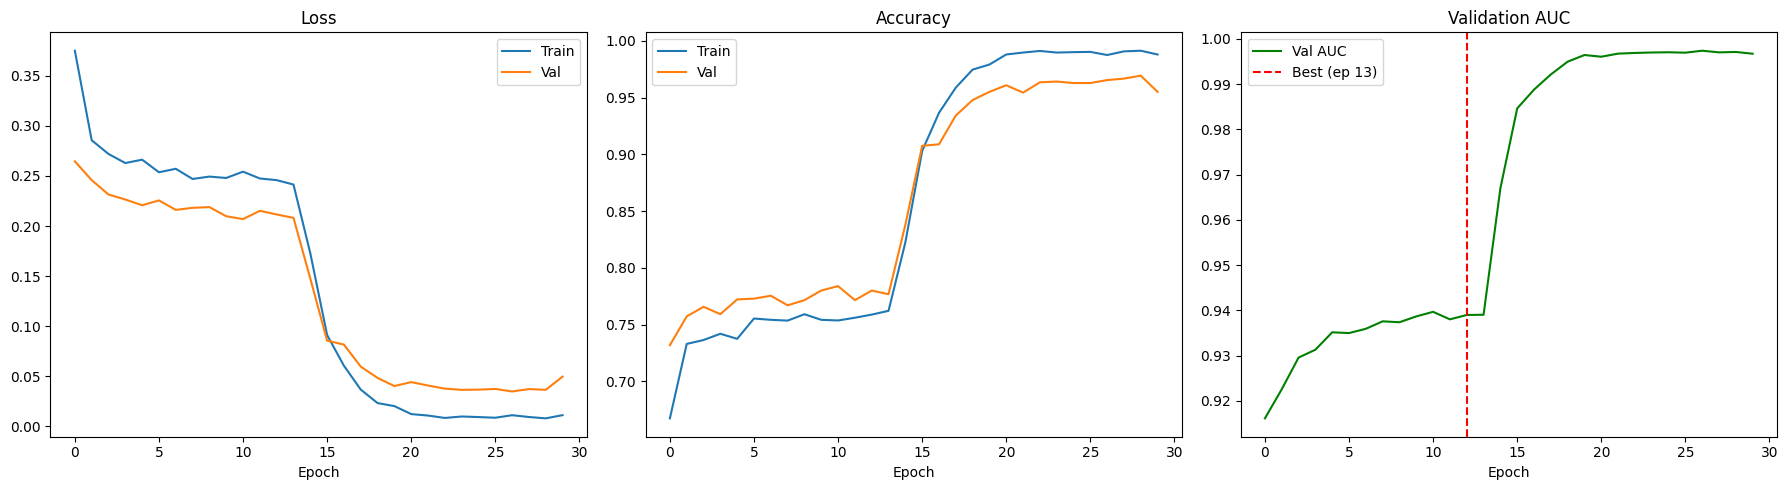

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history["val_auc"], label="Val AUC", color="green")
axes[2].axvline(x=best_epoch - 1, color="red", linestyle="--", label=f"Best (ep {best_epoch})")
axes[2].set_title("Validation AUC"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

# **Cell 17: Evaluate on Test Set**

In [17]:
model.load_state_dict(torch.load("best_alzheimer_efficientnet.pth"))
test_loss, test_acc, test_auc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.dataset.classes))

Test Loss: 0.0701 | Test Acc: 0.9242 | Test AUC: 0.9906

Classification Report:
                      precision    recall  f1-score   support

     Mild Impairment       0.91      0.97      0.94       179
 Moderate Impairment       1.00      1.00      1.00        12
       No Impairment       0.91      0.96      0.94       640
Very Mild Impairment       0.95      0.85      0.89       448

            accuracy                           0.92      1279
           macro avg       0.94      0.94      0.94      1279
        weighted avg       0.93      0.92      0.92      1279



# **Cell 18: Plot Confusion Matrix**

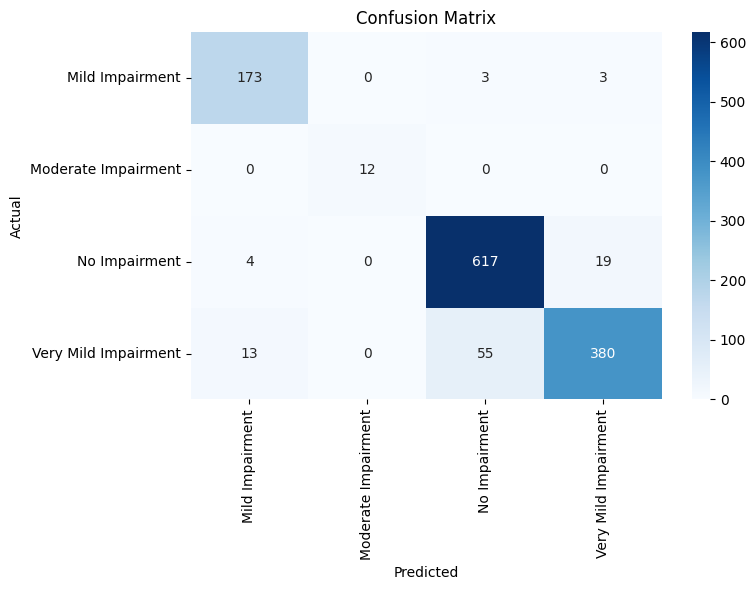

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=train_dataset.dataset.classes,
            yticklabels=train_dataset.dataset.classes)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

# **Cell 19: Interpretability with Grad-CAM**

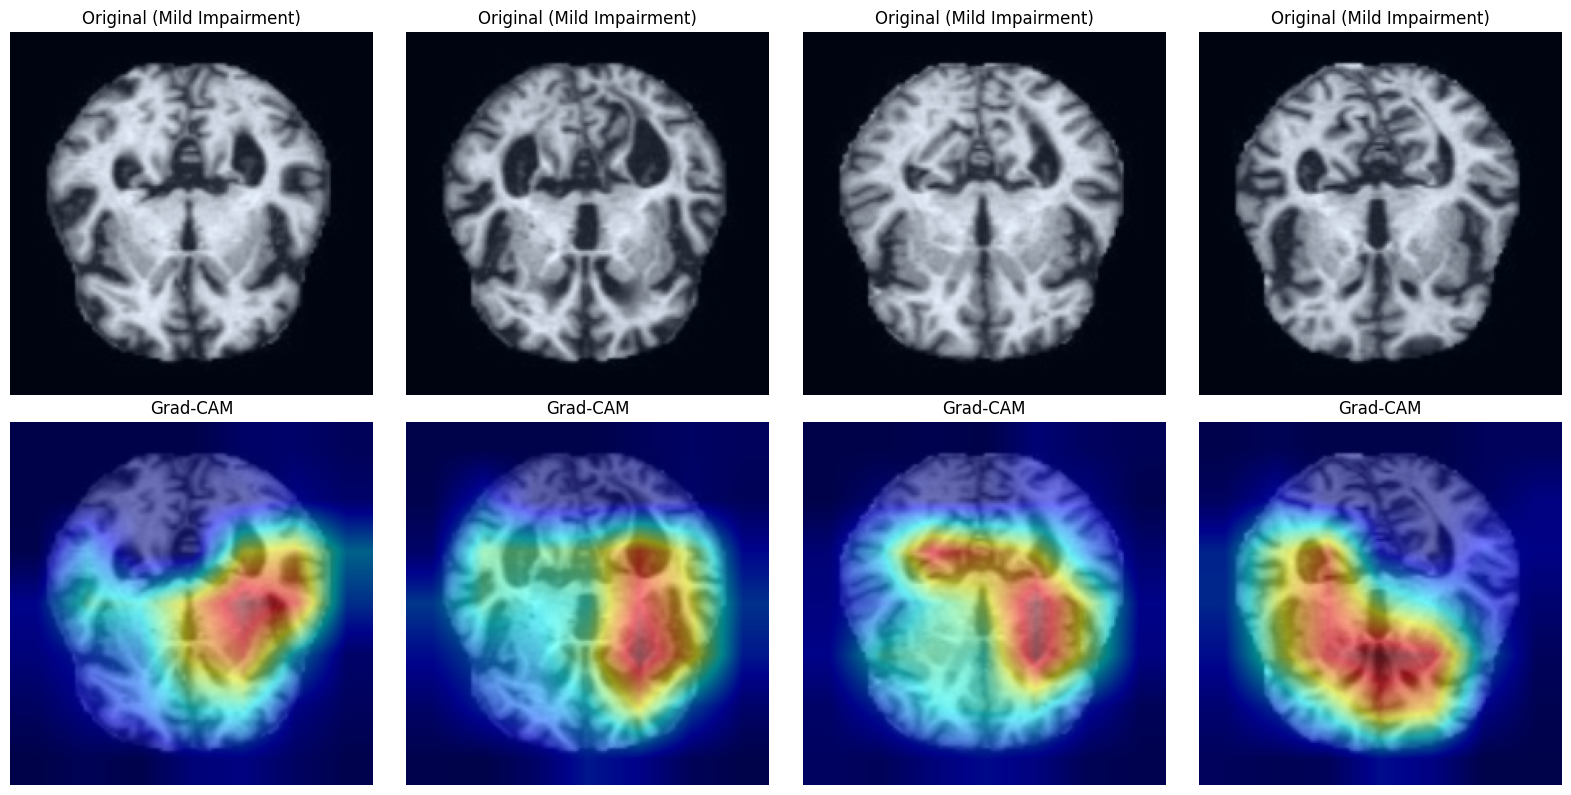

In [19]:
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:4].to(device)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_tensor = sample_images[i:i+1]
    grayscale_cam = cam(input_tensor=img_tensor,
                        targets=[ClassifierOutputTarget(sample_labels[i].item())])[0]

    img_np = img_tensor[0].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"Original ({train_dataset.dataset.classes[sample_labels[i]]})")
    axes[0, i].axis("off")
    axes[1, i].imshow(cam_image)
    axes[1, i].set_title("Grad-CAM")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150)
plt.show()

# **Cell 20: Save Model Weights and Config**

In [20]:
torch.save(model.state_dict(), "alzheimer_efficientnet_b0_weights.pth")

config = {
    "architectures": ["EfficientNetForImageClassification"],
    "model_type": "efficientnet",
    "num_labels": 4,
    "id2label": {i: name for i, name in enumerate(train_dataset.dataset.classes)},
    "label2id": {name: i for i, name in enumerate(train_dataset.dataset.classes)},
}
with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Files saved:")
print("  - alzheimer_efficientnet_b0_weights.pth")
print("  - config.json")

Files saved:
  - alzheimer_efficientnet_b0_weights.pth
  - config.json


# **Cell 21: Download Files from Colab**

In [21]:
from google.colab import files

files.download("alzheimer_efficientnet_b0_weights.pth")
files.download("config.json")
files.download("training_history.png")
files.download("results.png")
files.download("gradcam.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>